<a href="https://colab.research.google.com/github/nfcr7/PrototypePFA/blob/main/prototype1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# one time upload for dataset:
# https://www.kaggle.com/datasets/hassan06/nslkdd/data
# from google.colab import files
# uploaded = files.upload()
# Youssef : it wasn't working for me here, so I uploaded the train and test datasets manually.

In [6]:
#libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#additionla for more models to be trained, tested then evaluated
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt

In [7]:
#i ll re read these headers when i am actually free, for now here what i got gened:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label','difficulty'
]

In [8]:
# already split thank god
train = pd.read_csv("KDDTrain+.txt", names=columns)
test = pd.read_csv("KDDTest+.txt", names=columns)

print(train.shape)
print(test.shape)

(125973, 43)
(22544, 43)


In [9]:
#drof diff column, idk why
# Youssef : hey khalil so we drop the diff column here because it not used in the classification
train = train.drop("difficulty", axis=1)
test = test.drop("difficulty", axis=1)

In [10]:
#convert attacks to 1 and non attacks to 0
train['label'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['label'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [11]:
#encode categorial columns, service flag, etcc..
categorical_cols = ['protocol_type','service','flag']

encoder = LabelEncoder()

for col in categorical_cols:
    encoder.fit(train[col])
    train[col] = encoder.transform(train[col])
    test[col] = encoder.transform(test[col])

#this one is better because the taining and test get the same transformation
    #for col in categorical_cols:
   # encoder.fit(train[col])
    #train[col] = encoder.transform(train[col])
    #test[col] = encoder.transform(test[col])

In [12]:
#split te targeted labeled and the features:
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

In [13]:
#normazize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# the selected models (all boxed together):
- Random Forest
- Decision Tree
- SVM
- KNN
- Logistic Regression
- Naive Bayes
- AdaBoost
- Gradient Boosting

In [14]:
models = {

    "Random Forest": RandomForestClassifier(n_estimators=100),

    "Decision Tree": DecisionTreeClassifier(),

    "SVM": SVC(),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Naive Bayes": GaussianNB(),

    "AdaBoost": AdaBoostClassifier(n_estimators=100),

    "Gradient Boosting": GradientBoostingClassifier(),

}

# train and evaluate the rest

In [15]:
results = {}

for name, model in models.items():

    print("Training:", name)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print("Accuracy:", accuracy)
    print("----------------------")

Training: Random Forest
Accuracy: 0.7688963804116394
----------------------
Training: Decision Tree
Accuracy: 0.7779453513129879
----------------------
Training: SVM
Accuracy: 0.7819375443577005
----------------------
Training: KNN
Accuracy: 0.7675656493967353
----------------------
Training: Logistic Regression
Accuracy: 0.7539034776437189
----------------------
Training: Naive Bayes
Accuracy: 0.7714247693399574
----------------------
Training: AdaBoost
Accuracy: 0.7904098651525905
----------------------
Training: Gradient Boosting
Accuracy: 0.8064229950319376
----------------------


# plot the results of these models

                 Model  Accuracy
7    Gradient Boosting  0.806423
6             AdaBoost  0.790410
2                  SVM  0.781938
1        Decision Tree  0.777945
5          Naive Bayes  0.771425
0        Random Forest  0.768896
3                  KNN  0.767566
4  Logistic Regression  0.753903


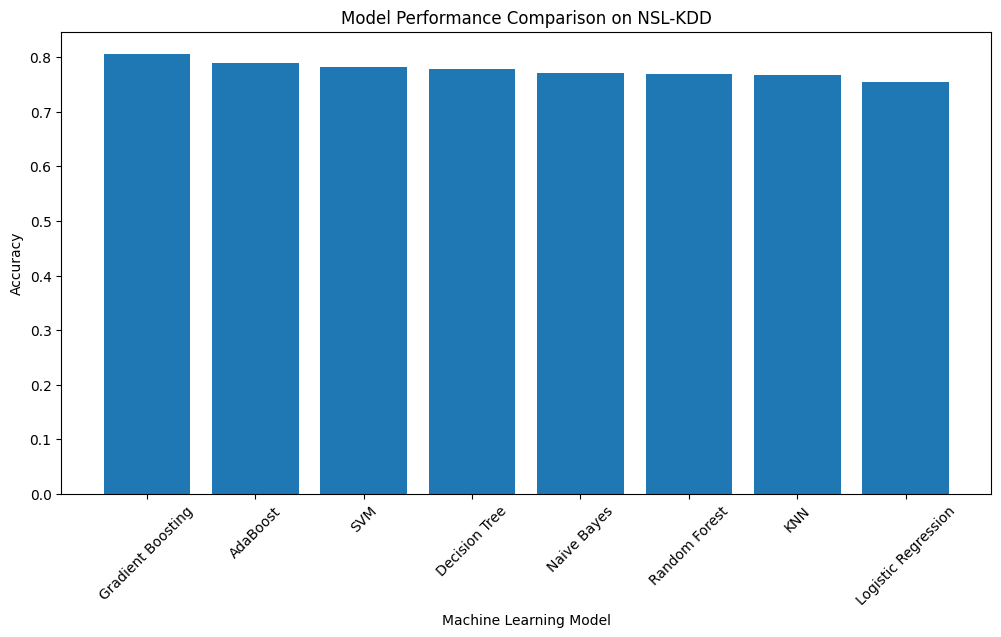

In [16]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

plt.figure(figsize=(12,6))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Performance Comparison on NSL-KDD")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

quick analyse :  what i found out is the why gradient boosting is the best model , it beceause of the way he handle problems he launch a lot of tree path and when a path get an errore the path after it learn from the mistake and resolve it that why ,

In [17]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

results = {}

for name, model in models.items():

    # measure training time
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    training_time = end - start

    # predictions
    y_pred = model.predict(X_test)

    # metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": training_time
    }

results_df = pd.DataFrame(results).T
print(results_df)

                     Precision    Recall  F1 Score  Training Time
Random Forest         0.965463  0.618639  0.754084      12.315691
Decision Tree         0.963776  0.626120  0.759093       1.018795
SVM                   0.975724  0.632666  0.767609      81.238370
KNN                   0.971205  0.609756  0.749162       0.030440
Logistic Regression   0.925178  0.617626  0.740748       4.171725
Naive Bayes           0.911399  0.662900  0.767537       0.138225
AdaBoost              0.963738  0.656511  0.780997      12.913195
Gradient Boosting     0.967706  0.674823  0.795152      29.632810


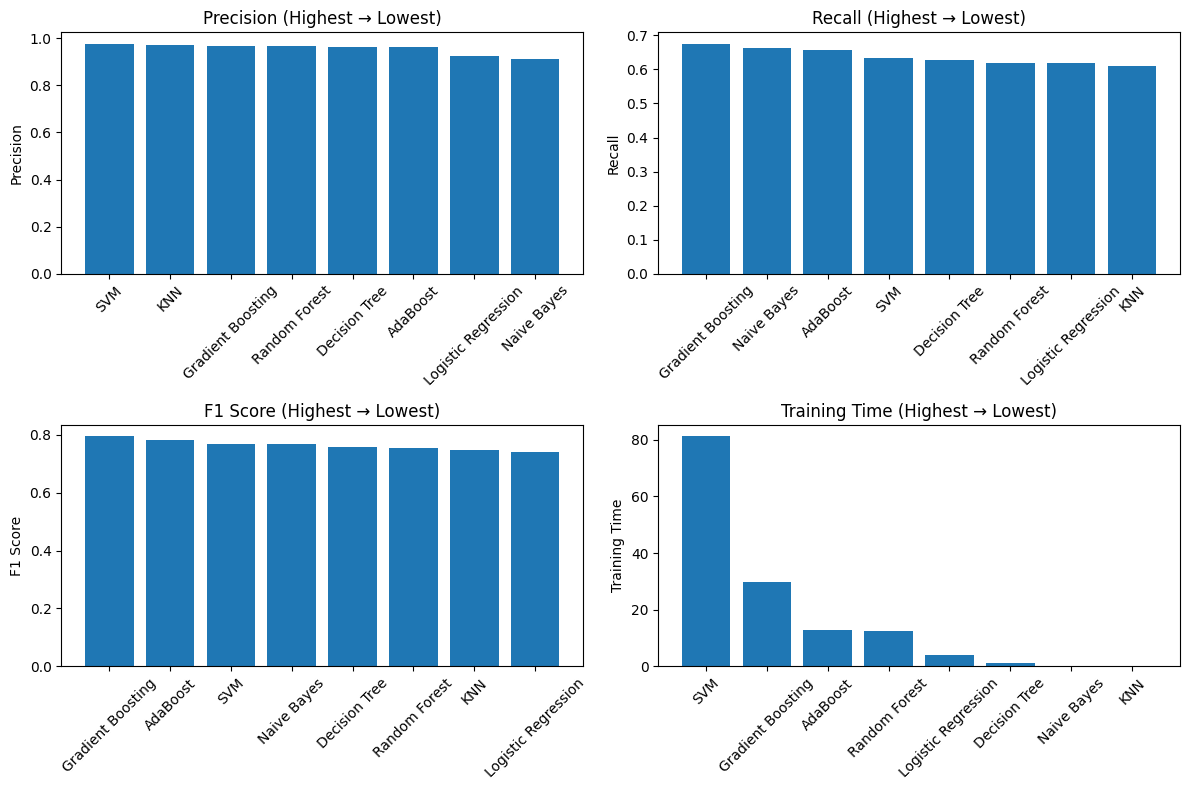

In [18]:

fig, axes = plt.subplots(2, 2, figsize=(12,8))

metrics = ["Precision", "Recall", "F1 Score", "Training Time"]

for ax, metric in zip(axes.flatten(), metrics):

    sorted_df = results_df.sort_values(by=metric, ascending=False)

    ax.bar(sorted_df.index, sorted_df[metric])
    ax.set_title(metric + " (Highest → Lowest)")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# results are close for all models, i am gonna dig throught the theory of these:
- what's an attack ?
- what defines an attack
- what do models prioretize in attacks
i ll mostly just read the training set in excel or json format
# gl hf

i ll add this box later to compare with training time:
'''''''''''
import time

start = time.time()
model.fit(X_train, y_train)
end = time.time()

training_time = end - start
'''''''

Youssef_here : Quick Update ive made the table containing time with accuracy recal f1 score and time